# Théorème de convergence des martingales de Doob — illustrations numériques

**Théorème (Doob).** Soit $(X_n)_{n\ge 0}$ une sous-martingale relativement à une filtration $(\mathcal{F}_n)_{n\ge 0}$, telle que
$$\sup_{n\ge 0}\mathbb{E}[X_n^+]<\infty.$$
Alors $X_n \xrightarrow{\text{p.s.}} X_\infty$ avec $\mathbb{E}[|X_\infty|]<\infty$.

Ce notebook met le résultat en évidence par quatre expériences, chacune ciblant une facette précise :

| # | Expérience | Ce qu'elle illustre |
|---|---|---|
| 1 | Urne de Pólya | Martingale **bornée** : convergence p.s. vers une limite **aléatoire** (loi Beta) |
| 2 | Martingale exponentielle | Convergence p.s. vers $0$ **sans** convergence $L^1$ (défaut d'intégrabilité uniforme) |
| 3 | Inégalité des montées | Le **mécanisme de la preuve** : $\sup_n \mathbb{E}[U_n[a,b]] < \infty$ |
| 4 | Marche aléatoire simple | **Contre-exemple** : hypothèse $\sup_n\mathbb{E}[X_n^+]<\infty$ violée, pas de convergence |


## Cellule 0 — Imports et configuration

Rien d'exotique : `numpy` pour les simulations vectorisées, `scipy.stats` pour les lois de référence et le test de Kolmogorov–Smirnov, `matplotlib` pour les tracés. On fixe la graine du générateur (`default_rng(42)`) pour la reproductibilité — toutes les trajectoires de ce notebook sont donc déterministes à ré-exécution identique.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 1. Urne de Pólya — martingale bornée, limite aléatoire

### Le modèle
Une urne contient initialement $a$ boules rouges et $b$ boules bleues. À chaque étape, on tire une boule uniformément, on la remet **avec une boule supplémentaire de la même couleur**. Soit $M_n = \dfrac{R_n}{R_n + B_n}$ la proportion de rouges après $n$ tirages.

### Pourquoi c'est une martingale
En notant $\mathcal{F}_n$ la tribu engendrée par les $n$ premiers tirages, et $T_n = a+b+n$ le nombre total de boules :
$$\mathbb{E}[M_{n+1}\mid \mathcal{F}_n] = M_n\cdot\frac{R_n+1}{T_n+1} + (1-M_n)\cdot\frac{R_n}{T_n+1} = \frac{R_n(T_n+1)}{T_n(T_n+1)} = M_n.$$

### Pourquoi le théorème s'applique trivialement
$M_n \in [0,1]$ : la martingale est bornée, donc *a fortiori* bornée dans $L^1$. La convergence p.s. est garantie. Le point instructif est **la nature de la limite** : $M_\infty$ n'est pas déterministe. On sait (échangeabilité + de Finetti, ou calcul direct des moments) que
$$M_\infty \sim \mathrm{Beta}(a, b).$$
Pour $a=b=1$, c'est la loi **uniforme** sur $[0,1]$ : chaque trajectoire se fige sur sa propre limite, et l'ensemble des limites remplit tout l'intervalle.

In [2]:
def polya_urn(n_steps, a=1, b=1, n_paths=1, rng=rng):
    '''Trajectoires de M_n = proportion de rouges. Sortie : (n_paths, n_steps+1).'''
    red = np.full(n_paths, a, dtype=float)
    total = float(a + b)
    props = np.empty((n_paths, n_steps + 1))
    props[:, 0] = red / total
    for t in range(1, n_steps + 1):
        draw_red = rng.random(n_paths) < red / total   # tirage vectorisé sur les n_paths urnes
        red += draw_red
        total += 1.0
        props[:, t] = red / total
    return props

### Trajectoires

On trace 30 trajectoires sur 3000 tirages. Observation attendue : les fluctuations s'amortissent en $O(1/n)$ (l'incrément $|M_{n+1}-M_n| \le 1/T_{n+1}$ est déterministe-ment petit), et chaque trajectoire **stabilise** — c'est la convergence p.s. rendue visible. Noter que les trajectoires ne convergent *pas* les unes vers les autres.

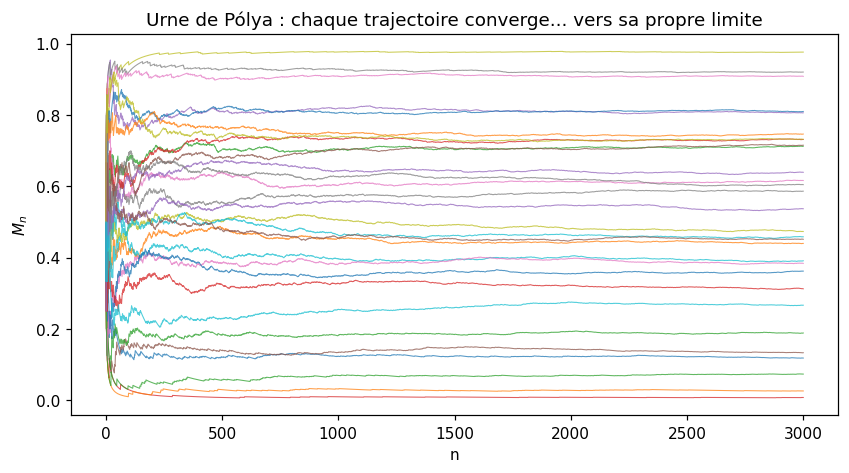

In [3]:
props = polya_urn(3000, a=1, b=1, n_paths=30)

fig, ax = plt.subplots(figsize=(9, 4.5))
for p in props:
    ax.plot(p, lw=0.7, alpha=0.75)
ax.set_xlabel("n"); ax.set_ylabel(r"$M_n$")
ax.set_title("Urne de Pólya : chaque trajectoire converge... vers sa propre limite")
plt.show()

### Loi de la limite $M_\infty$

On simule 5000 urnes indépendantes jusqu'à $n = 2000$ et on prend la valeur terminale comme proxy de $M_\infty$ (justifié : l'écart $|M_{2000} - M_\infty|$ est petit p.s., les incréments étant sommables en moyenne quadratique). On compare l'histogramme à la densité $\mathrm{Beta}(1,1)$ et on quantifie l'adéquation par un test de Kolmogorov–Smirnov.

Un $p$-value élevé (typiquement $> 0.05$) signifie que rien ne distingue l'échantillon de la loi uniforme — conforme à la théorie.

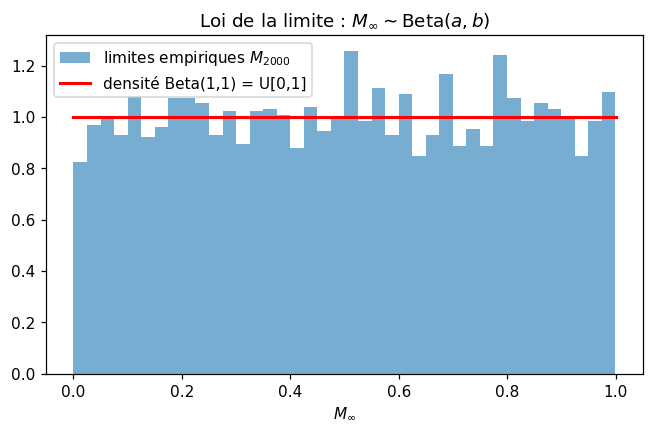

Test KS vs Beta(1,1) : statistique = 0.0099, p-value = 0.703


In [4]:
limits = polya_urn(2000, a=1, b=1, n_paths=5000)[:, -1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(limits, bins=40, density=True, alpha=0.6, label=r"limites empiriques $M_{2000}$")
x = np.linspace(0, 1, 200)
ax.plot(x, stats.beta(1, 1).pdf(x), "r-", lw=2, label="densité Beta(1,1) = U[0,1]")
ax.set_xlabel(r"$M_\infty$"); ax.legend()
ax.set_title(r"Loi de la limite : $M_\infty \sim \mathrm{Beta}(a,b)$")
plt.show()

ks = stats.kstest(limits, stats.beta(1, 1).cdf)
print(f"Test KS vs Beta(1,1) : statistique = {ks.statistic:.4f}, p-value = {ks.pvalue:.3f}")

## 2. Martingale exponentielle — convergence p.s. sans convergence $L^1$

### Le modèle
Soit $(Z_k)$ i.i.d. $\mathcal{N}(0,1)$ et
$$X_n = \prod_{k=1}^{n} e^{\sigma Z_k - \sigma^2/2}, \qquad X_0 = 1.$$
Chaque facteur a pour espérance $\mathbb{E}[e^{\sigma Z - \sigma^2/2}] = 1$ (transformée de Laplace gaussienne), donc $(X_n)$ est une **martingale positive** avec $\mathbb{E}[X_n] = 1$ pour tout $n$.

### Ce que dit le théorème — et ce qu'il ne dit pas
Martingale positive $\Rightarrow$ surmartingale positive $\Rightarrow$ convergence p.s. Mais vers quoi ? La loi des grands nombres appliquée aux logarithmes donne
$$\frac{1}{n}\log X_n = \frac{\sigma}{n}\sum_{k=1}^n Z_k - \frac{\sigma^2}{2} \xrightarrow{\text{p.s.}} -\frac{\sigma^2}{2} < 0,$$
donc $X_n \to 0$ **p.s.**, à vitesse exponentielle. Or $\mathbb{E}[X_n] = 1 \not\to 0 = \mathbb{E}[X_\infty]$ : la convergence n'a **pas lieu dans $L^1$**, la famille $(X_n)$ n'est pas uniformément intégrable, et la martingale n'est pas fermée ($X_n \ne \mathbb{E}[X_\infty\mid\mathcal{F}_n] = 0$).

C'est le prototype de la dichotomie de Kakutani pour les martingales produit.

In [5]:
def exp_martingale(n_steps, sigma=0.6, n_paths=1, rng=rng):
    '''X_n = prod exp(sigma*Z_k - sigma^2/2). Calcul en log pour la stabilité numérique.'''
    z = rng.standard_normal((n_paths, n_steps))
    log_incr = sigma * z - sigma**2 / 2
    log_x = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(log_incr, axis=1)], axis=1)
    return np.exp(log_x)

### Trajectoires et effondrement de l'estimateur Monte-Carlo

On trace 25 trajectoires (échelle log) plus la **moyenne empirique sur 2000 trajectoires** (courbe noire), à comparer à la valeur théorique $\mathbb{E}[X_n] = 1$ (ligne rouge).

Le phénomène clé : la moyenne empirique s'effondre elle aussi vers 0, alors que l'espérance vaut exactement 1. Ce n'est pas un bug — c'est **le mécanisme même de la non-intégrabilité uniforme rendu visible**. L'espérance est portée par des trajectoires atteignant des valeurs énormes avec une probabilité exponentiellement petite (grandes déviations : il faut $\bar{Z}_n \gtrsim \sigma/2$, événement de probabilité $\sim e^{-n\sigma^2/8}$), que 2000 tirages ne rencontrent jamais. La masse $L^1$ « fuit à l'infini ».

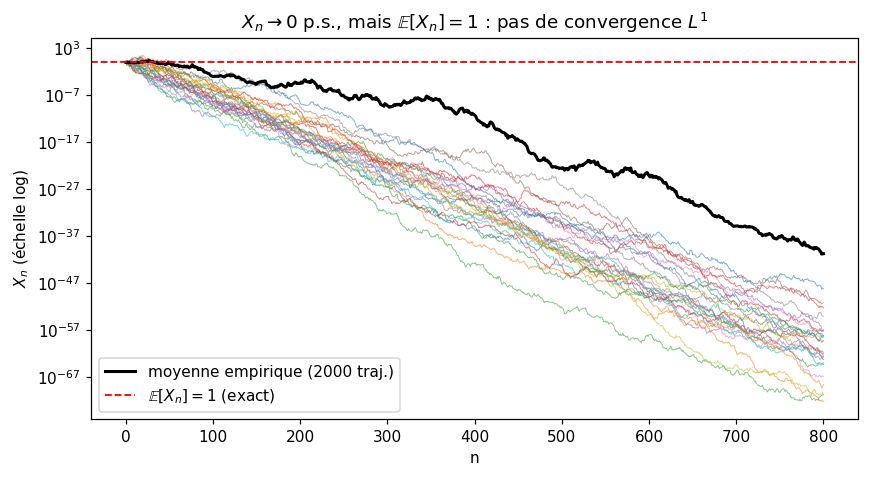

P(X_800 < 0.01) estimée : 1.000
Moyenne empirique de X_800 : 1.70e-41   (théorie : 1)
Pente empirique de log(X_n)/n : -0.1800   (théorie : -sigma^2/2 = -0.180)


In [6]:
N, PATHS = 800, 2000
X = exp_martingale(N, sigma=0.6, n_paths=PATHS)

fig, ax = plt.subplots(figsize=(9, 4.5))
for p in X[:25]:
    ax.plot(p, lw=0.6, alpha=0.6)
ax.plot(X.mean(axis=0), "k-", lw=2, label=fr"moyenne empirique ({PATHS} traj.)")
ax.axhline(1, color="red", ls="--", lw=1.2, label=r"$\mathbb{E}[X_n]=1$ (exact)")
ax.set_yscale("log")
ax.set_xlabel("n"); ax.set_ylabel(r"$X_n$ (échelle log)")
ax.set_title(r"$X_n \to 0$ p.s., mais $\mathbb{E}[X_n]=1$ : pas de convergence $L^1$")
ax.legend(loc="lower left")
plt.show()

print(f"P(X_800 < 0.01) estimée : {np.mean(X[:, -1] < 0.01):.3f}")
print(f"Moyenne empirique de X_800 : {X[:, -1].mean():.2e}   (théorie : 1)")
print(f"Pente empirique de log(X_n)/n : {np.log(X[:, -1]).mean()/N:.4f}   (théorie : -sigma^2/2 = {-0.6**2/2:.3f})")

## 3. L'inégalité des montées — le cœur de la preuve

### L'énoncé
Pour $a < b$, soit $U_n[a,b]$ le nombre de traversées montantes complètes de $[a,b]$ par $(X_0,\dots,X_n)$ (descendre sous $a$, puis remonter au-dessus de $b$). Pour une sous-martingale :
$$(b-a)\,\mathbb{E}\big[U_n[a,b]\big] \;\le\; \mathbb{E}\big[(X_n-a)^+\big] - \mathbb{E}\big[(X_0-a)^+\big].$$

### Pourquoi cela prouve le théorème
Sous $\sup_n \mathbb{E}[X_n^+] < \infty$, le membre de droite est borné uniformément en $n$, donc $\mathbb{E}[U_\infty[a,b]] < \infty$, donc $U_\infty[a,b] < \infty$ p.s. Or
$$\{\liminf X_n < \limsup X_n\} = \bigcup_{a<b,\; a,b\,\in\,\mathbb{Q}} \{U_\infty[a,b] = \infty\},$$
union dénombrable d'ensembles négligeables. Donc $\lim X_n$ existe p.s. dans $\bar{\mathbb{R}}$, et Fatou donne $\mathbb{E}[|X_\infty|] \le \liminf \mathbb{E}[|X_n|] < \infty$, d'où la finitude p.s.

### Vérification numérique
Sur l'urne de Pólya, on estime $\mathbb{E}[U_n[0.4,\,0.6]]$ par Monte-Carlo pour des horizons croissants, et on la compare à la borne de Doob $\mathbb{E}[(X_n - a)^+]/(b-a)$. Attendu : la courbe empirique **sature** (les trajectoires cessent de traverser une fois stabilisées) et reste sous la borne.

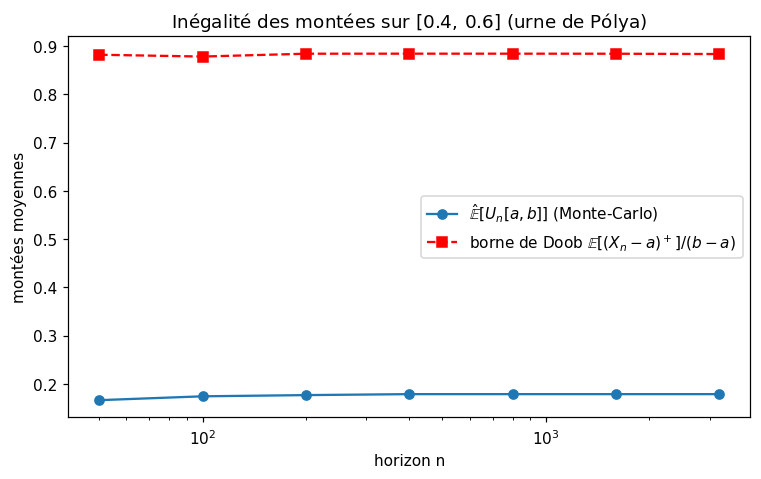

E[U_3200] ~ 0.178  <=  borne 0.884


In [7]:
def count_upcrossings(path, a, b):
    '''Nombre de traversées montantes complètes de [a,b].'''
    count, below = 0, path[0] <= a
    for x in path[1:]:
        if below and x >= b:
            count += 1
            below = False
        elif not below and x <= a:
            below = True
    return count

a_lvl, b_lvl = 0.4, 0.6
horizons = [50, 100, 200, 400, 800, 1600, 3200]
n_mc = 2000

full = polya_urn(max(horizons), a=1, b=1, n_paths=n_mc)
emp_up  = [np.mean([count_upcrossings(p[:n+1], a_lvl, b_lvl) for p in full]) for n in horizons]
bound   = [np.maximum(full[:, n] - a_lvl, 0).mean() / (b_lvl - a_lvl) for n in horizons]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(horizons, emp_up, "o-", label=r"$\hat{\mathbb{E}}[U_n[a,b]]$ (Monte-Carlo)")
ax.plot(horizons, bound, "s--", color="red", label=r"borne de Doob $\mathbb{E}[(X_n-a)^+]/(b-a)$")
ax.set_xscale("log")
ax.set_xlabel("horizon n"); ax.set_ylabel("montées moyennes")
ax.set_title(fr"Inégalité des montées sur $[{a_lvl},\,{b_lvl}]$ (urne de Pólya)")
ax.legend()
plt.show()

print(f"E[U_3200] ~ {emp_up[-1]:.3f}  <=  borne {bound[-1]:.3f}")

## 4. Contre-exemple — l'hypothèse n'est pas décorative

La marche aléatoire simple $X_n = \sum_{k\le n}\varepsilon_k$, $\varepsilon_k = \pm 1$ équiprobables, est une martingale. Mais
$$\mathbb{E}[X_n^+] = \tfrac{1}{2}\mathbb{E}[|X_n|] \sim \tfrac{1}{2}\sqrt{2n/\pi} \to \infty,$$
donc l'hypothèse du théorème est violée. Et de fait, il n'y a pas de convergence : par récurrence de la marche (ou loi du logarithme itéré),
$$\limsup_n X_n = +\infty, \qquad \liminf_n X_n = -\infty \quad \text{p.s.}$$
Graphiquement : les trajectoires oscillent indéfiniment dans une enveloppe d'ordre $\sqrt{n}$ (on trace $\pm 2.2\sqrt{n}$ à titre indicatif — l'enveloppe LIL exacte est $\sqrt{2n\log\log n}$).

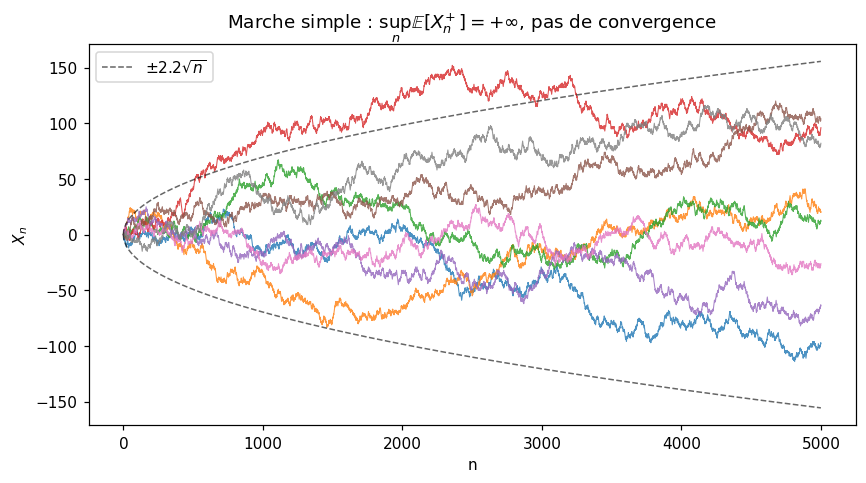

In [8]:
N, PATHS = 5000, 8
steps = rng.choice([-1, 1], size=(PATHS, N))
walks = np.concatenate([np.zeros((PATHS, 1)), np.cumsum(steps, axis=1)], axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
for w in walks:
    ax.plot(w, lw=0.7, alpha=0.8)
n_axis = np.arange(N + 1)
ax.plot(n_axis,  2.2*np.sqrt(n_axis), "k--", lw=1, alpha=0.6)
ax.plot(n_axis, -2.2*np.sqrt(n_axis), "k--", lw=1, alpha=0.6, label=r"$\pm 2.2\sqrt{n}$")
ax.set_xlabel("n"); ax.set_ylabel(r"$X_n$")
ax.set_title(r"Marche simple : $\sup_n \mathbb{E}[X_n^+] = +\infty$, pas de convergence")
ax.legend()
plt.show()

## Synthèse

| Expérience | Bornée $L^1$ ? | Conv. p.s. | Conv. $L^1$ | Enseignement |
|---|---|---|---|---|
| Pólya | oui (bornée) | oui, vers $M_\infty \sim \mathrm{Beta}$ | oui (UI par bornitude) | la limite est aléatoire |
| Exponentielle | oui ($\mathbb{E}[X_n]=1$) | oui, vers $0$ | **non** | p.s. $\not\Rightarrow$ $L^1$ ; masse qui fuit |
| Marche simple | **non** | **non** | non | l'hypothèse est nécessaire |

Le panel des montées relie le tout : la finitude p.s. de $U_\infty[a,b]$ pour tout $[a,b]$ rationnel est exactement ce qui interdit l'oscillation, et c'est cette quantité que l'hypothèse $\sup_n\mathbb{E}[X_n^+]<\infty$ contrôle via l'inégalité de Doob.

**Extensions possibles** : (a) théorème d'arrêt — arrêter la marche simple à la sortie de $\{-K,\dots,K\}$ la rend bornée donc convergente ; (b) version $L^p$, $p>1$ : vérifier numériquement $\|\sup_n |X_n|\|_p \le \frac{p}{p-1}\sup_n \|X_n\|_p$ ; (c) dichotomie de Kakutani en faisant varier $\sigma$.